# Ensembles pasivos Notebook
## 1. Introducción

En muchos problemas reales de aprendizaje automático, la distribución de los datos puede cambiar con el tiempo, lo que provoca que los modelos entrenados previamente pierdan rendimiento. Este fenómeno se conoce como *concept drift*.

El objetivo de este parte del trabajo es analizar el comportamiento de distintos métodos ensemble pasivo en presencia de concept drift. Para ello, se han implementado y evaluado varios algoritmos diseñados para adaptarse a cambios en los datos, comparando su rendimiento en diferentes escenarios de drift.

Los ensembles pasivos son aquellos que no disponen de un detector de drift


## Generacion de datasets

He utilizado como herramienta principal el repositorio de Calm-Data_Generator. En concreto los datasets son generados como streams por bloques.

Las pruebas las he hecho con dos generadores distintos SEA (más simple) y Agrawal (datos más complejos).

Se han considerado tres tipos de drift:

- **Abrupt drift**: el cambio de concepto ocurre de forma repentina entre bloques.
- **Gradual drift**: el cambio sucede de forma progresiva mezclando conceptos durante varios bloques consecutivos
- **Recurrent drift**: Conceptos anteriores reaparecen con el tiempo.


### Abrupt Drift

```python

def generate_abrupt():

    rng = np.random.RandomState(42)

    generators = []
    concepts = []

    for i in range(N_BLOCKS):

        concept = 0 if i < N_BLOCKS // 2 else 2

        block_seed = rng.randint(0, 100000)

        generators.append(
            synth.Agrawal(
                classification_function=concept,
                seed=block_seed
            )
        )

        concepts.append(concept)

    generate_dataset("agrawal_abrupt.csv", generators, concepts)

```


Durante los primeros bloques, los datos se generan utilizando una función de clasificación (concepto A). En un punto determinado, se cambia completamente a una segunda función (concepto B).

Este tipo de drift representa situaciones en las que el entorno cambia bruscamente, provocando una caída inmediata en el rendimiento de los modelos hasta que estos logran adaptarse al nuevo concepto.

### Gradual Drift 

```python
def generate_gradual():

    rng = np.random.RandomState(42)
    all_rows = []

    for i in range(N_BLOCKS):

        block_seed = rng.randint(0, 100000)

        gen_A = synth.Agrawal(classification_function=0, seed=block_seed)
        gen_B = synth.Agrawal(classification_function=2, seed=block_seed)

        stream_A = list(gen_A.take(SAMPLES_PER_BLOCK))
        stream_B = list(gen_B.take(SAMPLES_PER_BLOCK))

        for j, ((xA, yA), (xB, yB)) in enumerate(zip(stream_A, stream_B)):
        
            if i < 10:
                x, y = xA, yA
                concept = 0
            elif 10 <= i < 18:

                # transición entre bloques
                alpha_block = (i - 10) / (18 - 10)

                # transición dentro del bloque
                alpha_sample = j / SAMPLES_PER_BLOCK

                p = alpha_block * 0.7 + alpha_sample * 0.3

                if random.random() < p:
                    x, y = xB, yB
                    concept = 2
                else:
                    x, y = xA, yA
                    concept = 0
            else:
                x, y = xB, yB
                concept = 2

            row = dict(x)
            row["target"] = y
            row["block"] = i + 1
            row["concept"] = concept

            all_rows.append(row)

    df = pd.DataFrame(all_rows)
    df.to_csv(os.path.join(OUTPUT_DIR, "agrawal_gradual.csv"), index=False)
 ```



Selecciona probabilísticamente qué concepto utilizar para cada instancia. Esta probabilidad depende tanto del bloque como de la posición dentro del bloque.

No se si hay alguna forma de hacerlo más automatizado con Calm, he probado el uso de la clase Drift Injector pero creo que no era lo que yo intentaba conseguir y he tenido que hacer de forma manual la mezcla de datos dentro del mismo bloque.

### Recurrent Drift
```python
def generate_recurrent():

    rng = np.random.RandomState(42)

    generators = []
    concepts = []

    A = 0
    B = 2

    pattern = (
        [A]*5 +
        [B]*5 +
        [A]*4 +
        [B]*4 +
        [A]*4 +
        [B]*3
    )

    for concept in pattern:

        block_seed = rng.randint(0, 100000)

        generators.append(
            synth.Agrawal(
                classification_function=concept,
                seed=block_seed
            )
        )

        concepts.append(concept)

    generate_dataset("agrawal_recurrent.csv", generators, concepts)
```

Fuerzo un patron de alternanza


## Modelos

La implementación de cada uno de estos algoritmos la he basado en los papers originales recogidos en Krawczyk et al. (2017). En concreto estos algoritmos pertenecerían a 'Chunk based non stationary data streams' que es el caso de estudio.

He utilizado Hoeffding Trees como base learners para todos los algoritmos.
En cada iteracción se realiza evalución prequential: se predice con el bloque actual y luego se entrena el modelo con dicho bloque.


### SEA (Streaming Ensemble Algorithm)

SEA es un método sencillo basado en mantener un conjunto de clasificadores entrenados por bloques.

En cada iteración:

1. Se entrena un nuevo modelo con el bloque actual.
2. Se añade al ensemble.
3. Si se supera el tamaño máximo, se elimina el modelo con peor rendimiento.

La selección del modelo a eliminar se realiza evaluando su accuracy en un subconjunto del bloque actual.

A diferencia de otros métodos, SEA no utiliza pesos, sino un voting simple


Street, W. N., & Kim, Y. (2001, August). A streaming ensemble algorithm (SEA) for large-scale classification. In Proceedings of the seventh ACM SIGKDD international conference on Knowledge discovery and data mining (pp. 377-382).


### AUE2 (Accuracy Updated Ensemble)

El algoritmo AUE2 asigna un peso a cada modelo en función de su error en el bloque actual. La idea principal es que los modelos más precisos tengan mayor influencia en la predicción final.

En la implementación, cada vez que llega un nuevo bloque:

1. Se entrena un nuevo clasificador
2. Se añade al ensemble y se limita su tamaño máximo
3. Se recalculan los pesos de todos los modelos en función de su error

El cálculo del peso se realiza como:

w = 1 / (error + ε)

Esto implica que modelos con menor error reciben mayor peso.

Además, cuando el número de modelos supera el máximo permitido, se seleccionan los mejores clasificadores en función de sus pesos

La predicción final se obtiene mediante un voting ponderado, donde cada modelo contribuye según su peso.

D. Brzezinski and J. Stefanowski, "Reacting to Different Types of Concept Drift: The Accuracy Updated Ensemble Algorithm," in IEEE Transactions on Neural Networks and Learning Systems, vol. 25, no. 1, pp. 81-94, Jan. 2014, doi: 10.1109/TNNLS.2013.2251352

### WAE (Weighted Aging Ensemble)

WAE introduce un mecanismo de envejecimiento para controlar la influencia de los modelos antiguos.

Cada modelo recibe un peso en función de:
- su accuracy,
- y el número de iteraciones desde su creación.

El peso se calcula como:

w = accuracy / sqrt(iteraciones)

Esto implica que:
- los modelos precisos tienen más peso,
- los modelos antiguos pierden influencia con el tiempo.

Además, cuando el ensemble supera su tamaño máximo, se aplica un pruning basado en diversidad, eliminando el modelo cuya eliminación maximiza la diversidad del conjunto.

La predicción final se obtiene mediante un voting ponderado.

Woźniak, M. (2013, September). Application of combined classifiers to data stream classification. In IFIP International Conference on Computer Information Systems and Industrial Management (pp. 13-23). Berlin, Heidelberg: Springer Berlin Heidelberg.

### Learn++NSE

El algoritmo funciona en varias fases:

1. Se evalúa el rendimiento del ensemble actual sobre el nuevo bloque, obteniendo un error global.
2. Se construye una distribución de pesos sobre las instancias, dando mayor importancia a aquellas mal clasificadas.
3. Se entrena un nuevo clasificador.
4. Se evalúan todos los modelos utilizando esta distribución.
5. Se actualizan los pesos del ensemble.

El peso de cada modelo depende de su historial de errores, que se combina mediante una función sigmoide:

- Los modelos recientes reciben mayor peso.
- Los modelos antiguos pierden influencia progresivamente.

Este mecanismo permite adaptarse al drift sin eliminar completamente el conocimiento previo.

La predicción se realiza mediante un voting ponderado basado en estos pesos.


Incremental learning of concept drift in nonstationary environments
IEEE Transactions on Neural NetworksISSN: 10459227Volume: 22Issue: 10Pages: 1517 - 1531

## Evaluacion

El script test_ensembles.py permite ejecutar experimentos sobre los dataset generados y comparar resultados

La evaluacion se realiza mediante el esquema prequential por bloque. En cada iteracion:
1. El modelo realiza predicciones del bloque actual
2. Se calcula el rendimiento
3. El modelo se entrena con el mismo bloque

Cada experimento tiene varias runs y los resultados se obtienen promediando las metricas de las ejecuciones.

Las metricas que he utilizado son:

- Accuracy: mide la proporcion de predicciones correctas
- Min Accuracy: para ver el impacto del drift en el peor momento
- Recovery: bloques que transcurren para recuparar el rendimiento
- Kappa: mide el acuerdo teniendo en cuenta el azar.

## Resultados Generador Agrawal

In [1]:
from dataset_generator import generate_abrupt, generate_gradual, generate_recurrent
generate_recurrent()
generate_gradual()
generate_abrupt()

/home/eduardo/tfg/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generated 20000 samples in 25 blocks at: datasets/agrawal_recurrent.csv
Dataset generado: datasets/agrawal_recurrent.csv
Generated 20000 samples in 25 blocks at: datasets/agrawal_abrupt.csv
Dataset generado: datasets/agrawal_abrupt.csv


In [9]:
from test_ensembles import run_experiment

res_recurrent = run_experiment("datasets/agrawal_recurrent.csv")
res_abrupt = run_experiment("datasets/agrawal_abrupt.csv")
res_gradual = run_experiment("datasets/agrawal_gradual.csv")

In [10]:
import pandas as pd
def results_to_df(results_dict):

    rows = []

    for model, m in results_dict.items():
        rows.append({
            "Model": model,
            "Accuracy": m["accuracy_mean"],
            "Std": m["accuracy_std"],
            "Min Accuracy": m["accuracy_min"],
            "Recovery": m["recovery"],
            "Kappa": m["kappa_mean"]
        })

    df = pd.DataFrame(rows)
    return df.sort_values(by="Accuracy", ascending=False).round(4)

In [11]:
df_recurrent = results_to_df(res_recurrent)
df_abrupt    = results_to_df(res_abrupt)
df_gradual   = results_to_df(res_gradual)

=== Gradual Drift ===


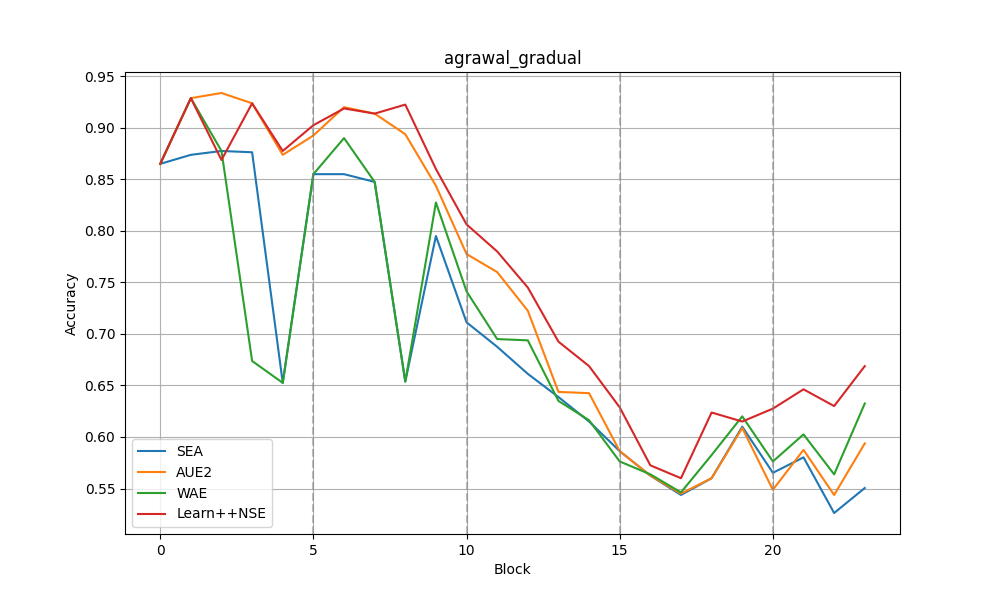

In [12]:
from IPython.display import Image, display
print("=== Gradual Drift ===")
df_gradual.style.background_gradient(cmap="Oranges")
display(Image(filename="plots/agrawal_gradual.png"))

=== Recurrent Drift ===


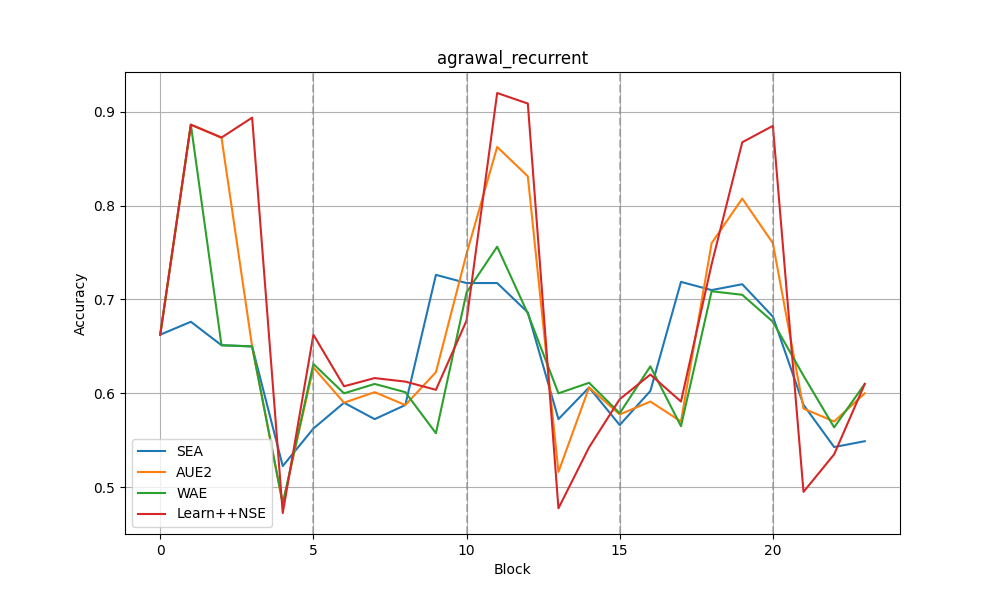

In [13]:
print("=== Recurrent Drift ===")
df_recurrent.style.background_gradient(cmap="Greens")
display(Image(filename="plots/agrawal_recurrent.png"))

=== Abrupt Drift ===


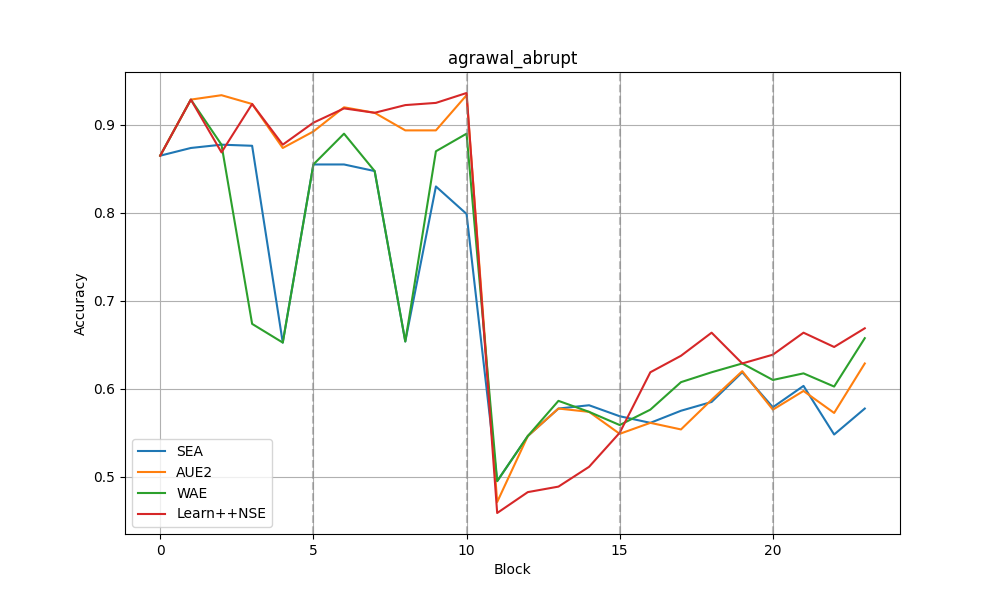

In [14]:
print("=== Abrupt Drift ===")
df_abrupt.style.background_gradient(cmap="Blues")
display(Image(filename="plots/agrawal_abrupt.png"))

## Resultados Generador SEA

In [15]:
from sea_generator import generate_abrupt, generate_gradual, generate_recurrent
generate_recurrent()
generate_gradual()
generate_abrupt()

Generated 20000 samples in 25 blocks at: datasets/sea_recurrent.csv
Dataset generado: datasets/sea_recurrent.csv
Dataset generado: datasets/sea_gradual.csv
Generated 20000 samples in 25 blocks at: datasets/sea_abrupt.csv
Dataset generado: datasets/sea_abrupt.csv


In [16]:
from test_ensembles import run_experiment

sea_recurrent = run_experiment("datasets/sea_recurrent.csv")
sea_abrupt = run_experiment("datasets/sea_abrupt.csv")
sea_gradual = run_experiment("datasets/sea_gradual.csv")

In [17]:
dfs_recurrent = results_to_df(sea_recurrent)
dfs_abrupt    = results_to_df(sea_abrupt)
dfs_gradual   = results_to_df(sea_gradual)

In [18]:
print("=== Gradual Drift ===")
dfs_gradual.style.background_gradient(cmap="Oranges")

=== Gradual Drift ===


,Model,Accuracy,Std,Min Accuracy,Recovery,Kappa
3,Learn++NSE,0.920600,0.012500,0.897500,1,0.806900
2,WAE,0.920300,0.012300,0.897500,1,0.806900
1,AUE2,0.919500,0.012000,0.897500,1,0.807300
0,SEA,0.918700,0.011200,0.897500,1,0.804000


In [19]:
print("=== Recurrent Drift ===")
dfs_recurrent.style.background_gradient(cmap="Greens")

=== Recurrent Drift ===


,Model,Accuracy,Std,Min Accuracy,Recovery,Kappa
3,Learn++NSE,0.918600,0.015300,0.865000,1,0.799400
1,AUE2,0.915900,0.015500,0.863700,3,0.796300
2,WAE,0.914000,0.016500,0.868800,4,0.793100
0,SEA,0.913800,0.013300,0.885000,3,0.791500


In [20]:
print("=== Abrupt Drift ===")
dfs_abrupt.style.background_gradient(cmap="Blues")

=== Abrupt Drift ===


,Model,Accuracy,Std,Min Accuracy,Recovery,Kappa
3,Learn++NSE,0.924000,0.012300,0.897500,1,0.809500
2,WAE,0.921700,0.011900,0.897500,1,0.808100
1,AUE2,0.921500,0.012200,0.897500,1,0.808700
0,SEA,0.920400,0.011400,0.897500,1,0.805300
